# Package

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from datetime import date
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [58]:
# input data
df = pd.read_excel(r"C:\Users\asus\OneDrive\Desktop\Lengkap Berkas Skripsi\Data Skripsi\Curah Hujan_2011-2020_FIX.xlsx")

In [59]:
# Mengubah kolom 'Time' menjadi format datetime dengan format 'yyyy-mm-dd'
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d')

In [60]:
# Membuat variabel 'train_dates' yang berisi nilai waktu dari kolom 'Time'
train_dates = pd.to_datetime(df['Time'])

In [5]:
# Membuat variabel lag 
df['Temp_1'] = df['Temperature/°C'].shift(1)
df['Temp_2'] = df['Temperature/°C'].shift(2)
df['Dew_1'] = df['Dew Point/°C'].shift(1)
df['Hum_1'] = df['Humidity/%'].shift(1)
df['Hum_2'] = df['Humidity/%'].shift(2)
df['Hum_20'] = df['Humidity/%'].shift(20)
df['Hum_22'] = df['Humidity/%'].shift(22)
df['Press_1'] = df['Pressure/Mb'].shift(1)

In [6]:
# Membuat variabel lag untuk curah hujan (Rainfall) dengan pergeseran beberapa hari yang telah ditentukan
lag_ch = [1, 3, 4, 6, 7, 9, 10, 11, 12, 15, 16, 18, 21, 22, 24, 25, 26]
for i in lag_ch:
    df[f'Ch_lag{i}'] = df['Curah Hujan/mm'].shift(i)

In [7]:
# Membuat variabel rata-rata curah hujan berdasarkan jendela waktu dari 2 hingga 30 hari
window_ch = list(range(2, 31))
for i in window_ch:
    df[f'Ch_win{i}'] = df['Curah Hujan/mm'].rolling(window=i, min_periods=1).mean()

In [8]:
# Mengisi nilai yang hilang (NaN) dengan metode backfill (mengisi dengan nilai dari bawah ke atas)
df.fillna(method='bfill', inplace=True)
# Mengisi nilai yang hilang (NaN) dengan metode forward fill (mengisi dengan nilai dari atas ke bawah)
df.fillna(method='ffill', inplace=True)

C:\Users\asus\AppData\Local\Temp\ipykernel_13140\2711203625.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)
C:\Users\asus\AppData\Local\Temp\ipykernel_13140\2711203625.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [9]:
# Menghapus kolom 'Time' dari DataFrame
df_final = df.drop('Time', axis=1)

In [10]:
# Memisahkan data menjadi data latih (2011-2019) dan data uji (2020)
# Data latih: 3287 data, Data uji: 366 data
# Menghapus kolom 'Curah Hujan/mm' dari fitur (X)
X = df_final.drop('Curah Hujan/mm', axis=1)
y = df_final['Curah Hujan/mm']

In [11]:
# Memisahkan data latih dan data uji berdasarkan indeks
train_x, train_y = X[:3287], y[:3287]
test_x, test_y = X[3287:], y[3287:]

In [12]:
# Menerapkan scaling pada data latih dan data uji
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a fu

# XGBoost

In [13]:
# Membuat model XGBRegressor dengan parameter n_estimators=1000 dan learning_rate=0.1
model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)

In [14]:
# Melatih model menggunakan data latih dan menilai dengan metrik RMSE dan MAE pada data latih dan data uji
model.fit(train_x, train_y, eval_metric=["rmse", "mae"], eval_set=[(train_x, train_y), (test_x, test_y)], verbose=True)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:5.81093	validation_0-mae:3.86127	validation_1-rmse:17.85184	validation_1-mae:10.34381
[1]	validation_0-rmse:5.39874	validation_0-mae:3.56933	validation_1-rmse:16.97974	validation_1-mae:9.69456
[2]	validation_0-rmse:5.01309	validation_0-mae:3.29876	validation_1-rmse:16.21657	validation_1-mae:9.12733
[3]	validation_0-rmse:4.67140	validation_0-mae:3.05482	validation_1-rmse:15.59403	validation_1-mae:8.60474
[4]	validation_0-rmse:4.35565	validation_0-mae:2.83863	validation_1-rmse:14.98210	validation_1-mae:8.12425
[5]	validation_0-rmse:4.08608	validation_0-mae:2.63409	validation_1-rmse:14.45874	validation_1-mae:7.73938
[6]	validation_0-rmse:3.81680	validation_0-mae:2.45494	validation_1-rmse:13.94708	validation_1-mae:7.31750
[7]	validation_0-rmse:3.59388	validation_0-mae:2.29317	validation_1-rmse:13.41823	validation_1-mae:6.95193
[8]	validation_0-rmse:3.37350	validation_0-mae:2.15135	validation_1-rmse:12.80373	validation_1-mae:6.56090
[9]	validation_0-rmse:3.18370	valida

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [15]:
# Membuat prediksi pada data latih
train_pred = model.predict(train_x)

In [16]:
# Menghitung metrik evaluasi pada data latih
mse_train = mean_squared_error(train_y, train_pred)
mae_train = mean_absolute_error(train_y, train_pred)
rmse_train = np.sqrt(mse_train)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseD

In [17]:
# Membuat prediksi untuk data uji
pred = model.predict(test_x)

In [18]:
# Menghitung MSE, MAE, RMSE untuk data uji
mse_test = mean_squared_error(test_y, pred)
mae_test = mean_absolute_error(test_y, pred)
rmse_test = np.sqrt(mse_test)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseD

In [19]:
# Membuat plot untuk membandingkan data aktual vs prediksi pada data uji
# Mengambil data tahun untuk data uji
year_test = df['Time'][3287:]

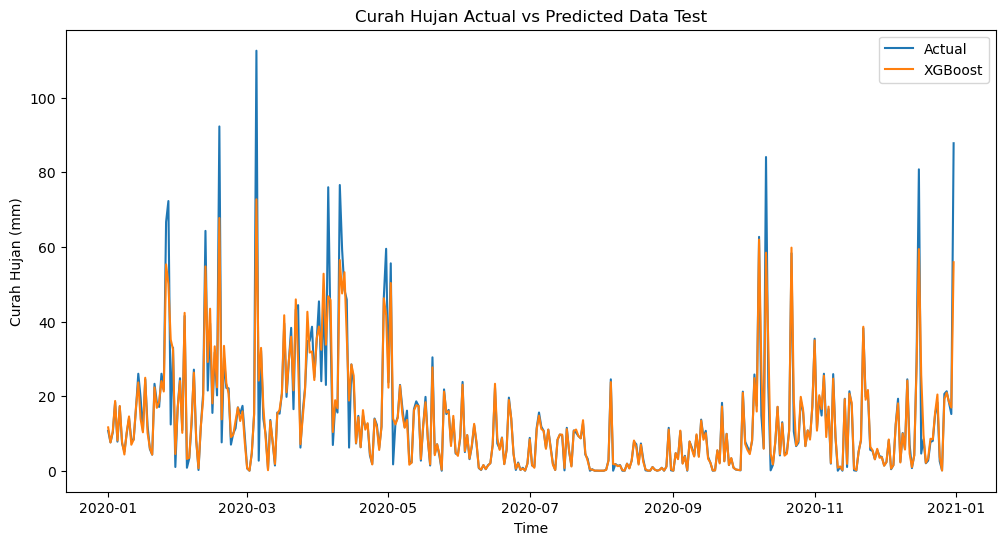

In [20]:
# Membuat plot data aktual dan prediksi untuk data uji
plt.figure(figsize=(12, 6))
plt.plot(year_test, test_y, label='Actual')
plt.plot(year_test, pred, label='XGBoost')
plt.title('Curah Hujan Actual vs Predicted Data Test')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

# LSTM

In [21]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import RMSprop, Adam
import random
import tensorflow as tf
random_seed = 123
random.seed(random_seed)
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

In [22]:
# Menghapus kolom 'Time' dari DataFrame
time = df[['Time']]
df_akhir = df.drop(['Time'], axis = 1)

In [23]:
# Melakukan normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_akhir)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a fu

In [24]:
# Mendefinisikan panjang urutan dan jumlah fitur
sequence_length = 1
num_features = len(df_akhir.columns)

In [25]:
# Membuat urutan data dan label yang sesuai
sequences = []
labels = []
for i in range(len(scaled_data) - sequence_length):
    seq = scaled_data[i:i + sequence_length]
    label = scaled_data[i + sequence_length][5]  # Mengambil label dari kolom ke-5 yang merupakan 'Curah Hujan/mm'
    sequences.append(seq)
    labels.append(label)

In [26]:
# Mengubah daftar menjadi array numpy
sequences = np.array(sequences)
labels = np.array(labels)

In [27]:
# Membagi data menjadi data latih (2011-2019) dan data uji (2020). 
# Total 3287 data latih dan 366 data uji
train_x, train_y = sequences[:3287], labels[:3287]
test_x, test_y = sequences[3287:], labels[3287:]

In [28]:
# Membuat model LSTM
model = Sequential()
model.add(LSTM(20, input_shape=(sequence_length, num_features), return_sequences = False, activation='tanh'))
model.add(Dense(1))

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
# Early stopping untuk mencegah overfitting
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

In [30]:
# Mengompilasi model dengan optimizer Adam dan loss function MSE
model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,501 (25.39 KB)

 Trainable params: 6,501 (25.39 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Melatih model dengan data latih, dengan validasi 10% dari data latih
history = model.fit(train_x, train_y, epochs = 100, batch_size = 64, validation_split = 0.1,
                    verbose = 1, callbacks = [early_stopping])

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2963 - val_loss: 1.3318
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2537 - val_loss: 1.2161
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2473 - val_loss: 1.2339
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2433 - val_loss: 1.2030
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2362 - val_loss: 1.2212
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2294 - val_loss: 1.2612
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2232 - val_loss: 1.3364
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2158 - val_loss: 1.2960
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2068 - val_loss: 1.3389
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1969 - val_loss: 1.3435
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1864 - val_loss: 1.3902
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [32]:
# Mengevaluasi model terbaik pada data uji
test_loss = model.evaluate(test_x, test_y)
print("Test Loss:", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3065 
Test Loss: 3.393495559692383


In [33]:
# Membuat prediksi untuk data uji menggunakan model yang sudah dilatih
predictions = model.predict(test_x)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [34]:
# Mengambil nilai aktual curah hujan pada data uji
test_y_copies = np.repeat(test_y.reshape(-1, 1), test_x.shape[-1], axis=-1)
true_rain = scaler.inverse_transform(test_y_copies)[:, 5]

In [35]:
# Mengambil nilai prediksi curah hujan pada data uji
prediction = model.predict(test_x)
prediction_copies = np.repeat(prediction, 60, axis = -1)
predicted_rain = scaler.inverse_transform(prediction_copies)[:, 5]

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


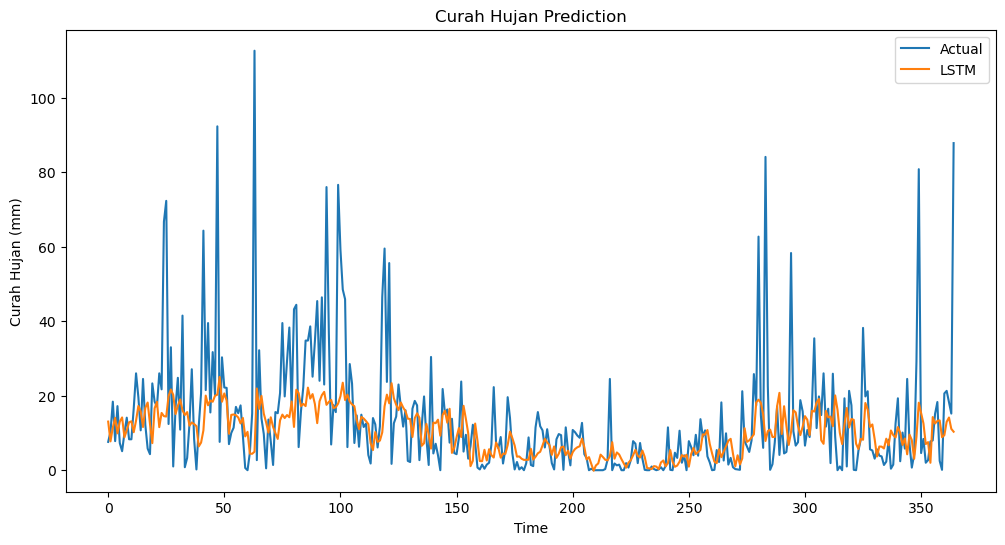

In [36]:
# Membuat plot nilai aktual dan prediksi curah hujan pada data uji
plt.figure(figsize=(12, 6))
plt.plot(true_rain, label='Actual')
plt.plot(predicted_rain, label='LSTM')
plt.title('Curah Hujan Prediction')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

# Perbandingan LSTM dan XGBoost

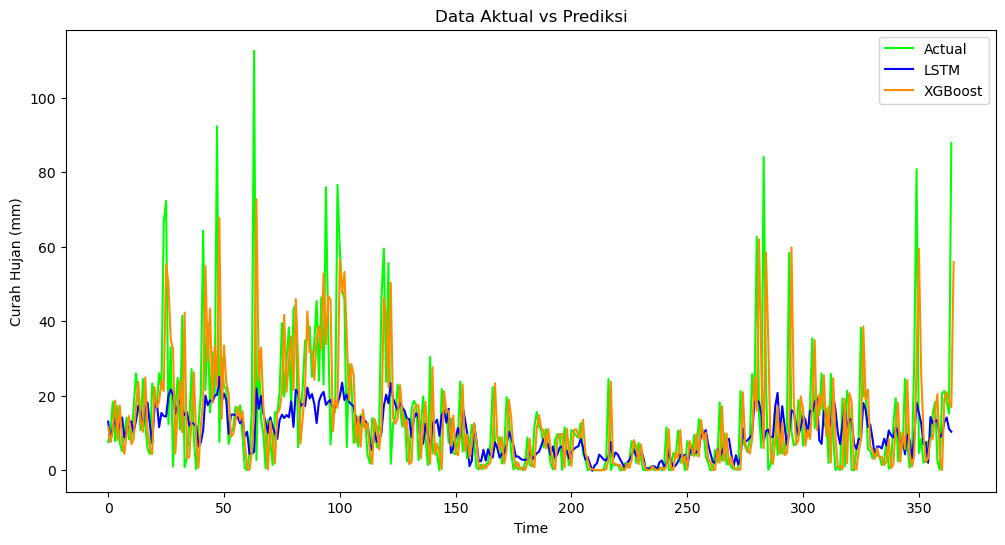

In [37]:
# Membuat plot gabungan
plt.figure(figsize=(12, 6))
plt.plot(true_rain, label='Actual', color='lime')
plt.plot(predicted_rain, label='LSTM', color='blue')
plt.plot(pred, label='XGBoost', color='darkorange')
plt.title('Data Aktual vs Prediksi')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

# Boxplot

In [7]:
#Membuat box plot
data_1 = df.loc[:, ['Curah Hujan/mm']]
print(data_1.head())
print(data_1.shape)

   Curah Hujan/mm
0             1.6
1             1.1
2             3.8
3             1.5
4             1.7
(3653, 1)


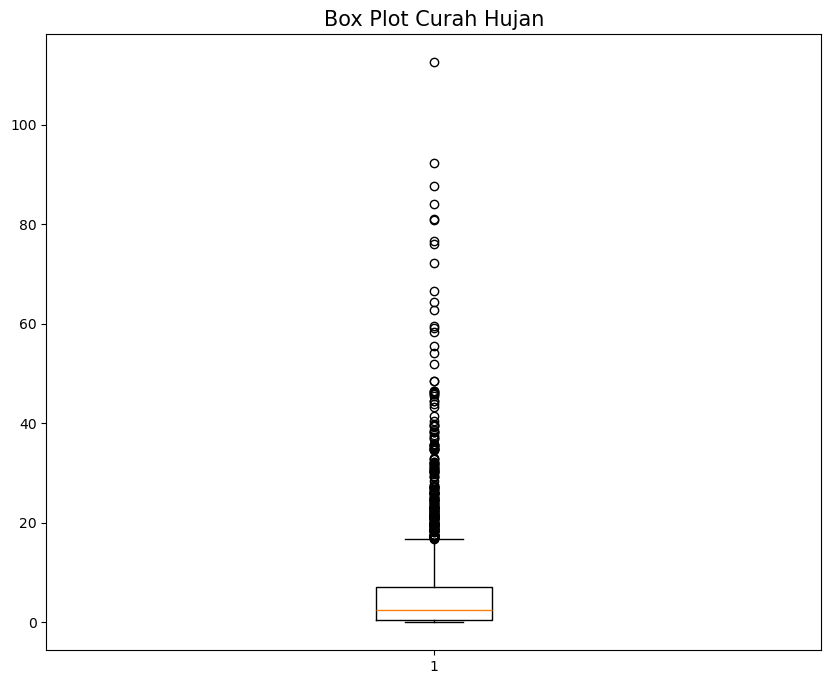

In [10]:
# membuat boxplot
plt.figure(figsize=(10, 8))
plt.boxplot(data_1)
plt.title('Box Plot Curah Hujan',fontsize=15) # Menambahkan judul label
plt.show() # Menampilkan plot


In [26]:
data = data_1  # data_1 adalah DataFrame yang Anda gunakan

# Hitung Q1, Q3 dan IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas untuk pencilan
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Identifikasi pencilan
pencilan = ((data < batas_bawah) | (data > batas_atas))
data_1['Pencilan'] = pencilan
data_pencilan = data_1.loc[data_1['Pencilan']]
print(data_pencilan)


      Curah Hujan/mm  Pencilan
9               17.6      True
109             23.2      True
112             27.3      True
144             19.4      True
303             20.6      True
...              ...       ...
3645            18.3      True
3648            20.6      True
3649            21.3      True
3650            18.3      True
3652            87.8      True

[247 rows x 2 columns]


In [48]:
batas_atas = Q3 + 1.5 * IQR
print(batas_atas)

Curah Hujan/mm    16.75
dtype: float64


In [29]:
# Hitung jumlah dan persentase pencilan
total_pencilan = data_pencilan.count()
total_data = data.count()
persentase_pencilan = (total_pencilan / total_data) * 100

print(persentase_pencilan)

Curah Hujan/mm    6.761566
Pencilan          6.761566
dtype: float64


In [24]:
data_pencilan = data_1[pencilan]

      Curah Hujan/mm
0              False
1              False
2              False
3              False
4              False
...              ...
3648            True
3649            True
3650            True
3651           False
3652            True

[3653 rows x 1 columns]


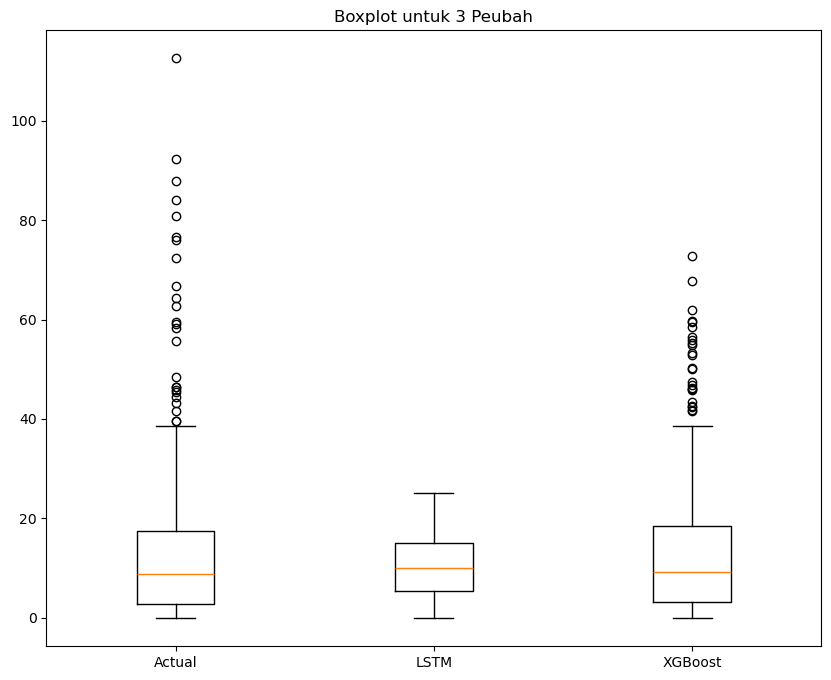

In [43]:
import matplotlib.pyplot as plt

# Contoh data
data1 = true_rain
data2 = predicted_rain
data3 = pred

# Menggabungkan data dalam satu list
data = [data1, data2, data3]
# ukuran
plt.figure(figsize=(10, 8))
# Membuat boxplot
plt.boxplot(data)
# Menambahkan label untuk sumbu x
plt.xticks([1, 2, 3], ['Actual', 'LSTM', 'XGBoost'])
# Menambahkan judul
plt.title('Boxplot untuk 3 Peubah')
# Menampilkan plot
plt.show()

# Plot Curah Hujan

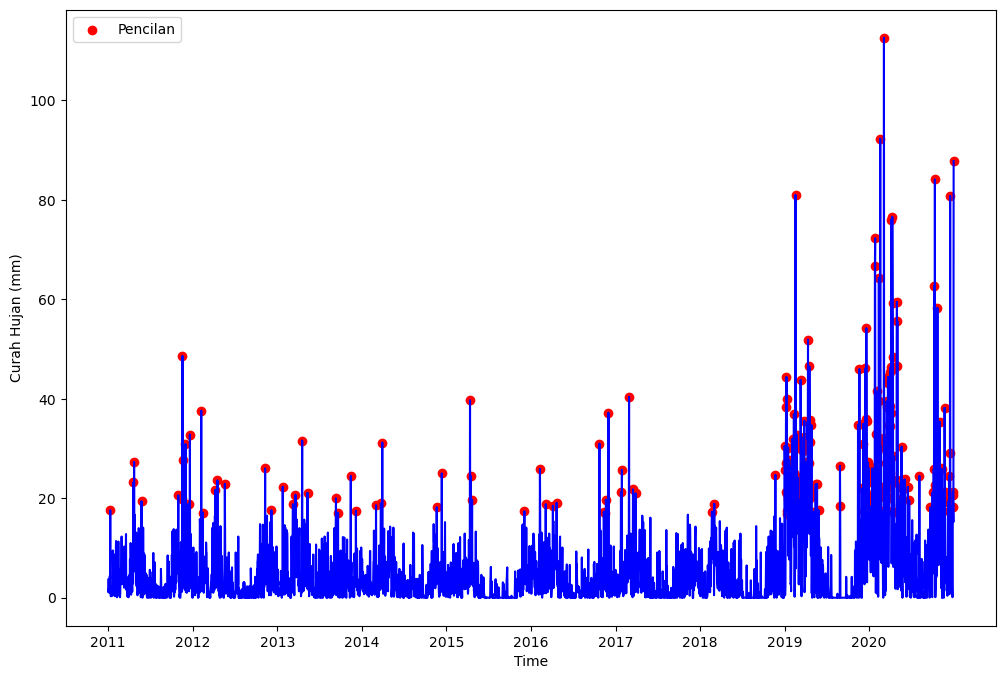

In [71]:

# membuat plot curah hujan harian
plt.figure(figsize=(12, 8)) # Plot data curah hujan
plt.plot(df.index, df['Curah Hujan/mm'], color='blue')
# Menentukan ambang batas pencilan, misalnya lebih dari 80 mm
outlier_threshold = 16.75
# Menyorot pencilan
outliers = df[df['Curah Hujan/mm'] > outlier_threshold]
plt.scatter(outliers.index, outliers['Curah Hujan/mm'], color='red', label='Pencilan')
plt.ylabel('Curah Hujan (mm)') # Menambahkan label pada sumbu y
years = pd.date_range(start=df.index.min(), end=df.index.max(), freq='YS') # Menampilkan hanya awal tiap tahun di sumbu x
plt.xticks(years, [year.year for year in years],)
plt.xlabel('Time') # Menambahkan label pada sumbu x
plt.legend()
plt.show() # Menampilkan plot